In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

In [2]:
data_train = pd.read_csv("feature-engineering-train.csv")
data_test = pd.read_csv("feature-engineering-test.csv")

X_train, y_train = data_train.drop(columns=["label"]), data_train["label"]
X_test, y_test = data_test.drop(columns=["label"]), data_test["label"]

X = pd.concat((X_train, X_test), axis=0)
y = pd.concat((y_train, y_test), axis=0)

In [3]:
from functools import reduce

binary_columns = [col for col in X.columns if col.startswith("B")]
discrete_columns = [col for col in X.columns if col.startswith("D")]
float_columns = [col for col in X.columns if col.startswith("F")]
object_columns = [col for col in X.columns if col.startswith("O")]

columns = reduce(
    np.union1d,
    (
        binary_columns,
        discrete_columns,
        float_columns,
        object_columns,
    ),
)
np.setdiff1d(X.columns, columns)

array([], dtype=object)

In [4]:
X = X.drop(columns=object_columns)
X_train = X_train.drop(columns=object_columns)
X_test = X_test.drop(columns=object_columns)

# 4. Transformation

In [ ]:
skew_after.abs() < skew_before.abs()

DDomainLength               True
DLargestLineLength          True
DLineOfCode                 True
DNoOfCSS                    True
DNoOfDigitsInDomain         True
DNoOfEmptyRef               True
DNoOfExternalRef            True
DNoOfHyphensInDomain        True
DNoOfImage                  True
DNoOfJS                     True
DNoOfObfuscatedChar         True
DNoOfPopup                  True
DNoOfSelfRef                True
DNoOfSpecialCharInDomain    True
DNoOfSubDomain              True
DNoOfTokensInDomain         True
DNoOfiFrame                 True
DTLDLength                  True
FAlphabetRatioInDomain      True
FDomainEntropy              True
FTLD                        True
FURLCharProb                True
dtype: bool

In [ ]:
kurt_after.abs() < kurt_before.abs()

DDomainLength                True
DLargestLineLength           True
DLineOfCode                  True
DNoOfCSS                     True
DNoOfDigitsInDomain          True
DNoOfEmptyRef                True
DNoOfExternalRef             True
DNoOfHyphensInDomain         True
DNoOfImage                   True
DNoOfJS                      True
DNoOfObfuscatedChar          True
DNoOfPopup                   True
DNoOfSelfRef                 True
DNoOfSpecialCharInDomain     True
DNoOfSubDomain               True
DNoOfTokensInDomain          True
DNoOfiFrame                  True
DTLDLength                  False
FAlphabetRatioInDomain       True
FDomainEntropy               True
FTLD                         True
FURLCharProb                 True
dtype: bool

In [ ]:
X_train["DTLDLength"].value_counts()

DTLDLength
 0.424646     99072
-0.806788     43409
-2.640820      8335
 1.824475      4709
 3.375001       592
 5.063206       367
 6.878989       246
 8.814213        42
 10.862139       16
 13.017067       14
 15.274089        5
 20.077798        1
Name: count, dtype: int64

# 1. Feature Selection

## 1.1. Mutual Information for Binary features

In [ ]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X_train, y_train)
mi = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
mi

DLineOfCode                 0.589068
DNoOfImage                  0.539189
DNoOfExternalRef            0.530928
DNoOfSelfRef                0.514154
DNoOfJS                     0.493481
DLargestLineLength          0.486992
DNoOfCSS                    0.441061
BHasSocialNet               0.387489
BHasCopyrightInfo           0.325323
BHasDescription             0.285996
BHasSubmitButton            0.187904
FTLD                        0.173792
DNoOfEmptyRef               0.172947
DNoOfiFrame                 0.172568
BIsResponsive               0.167239
BIsHTTPS                    0.162548
FDomainEntropy              0.151115
BHasDomainTitleMatch        0.147597
BHasHiddenFields            0.146588
BHasFavicon                 0.143465
FURLCharProb                0.138230
BHasTitle                   0.131381
FAlphabetRatioInDomain      0.121597
BHasURLTitleMatch           0.117906
DNoOfDigitsInDomain         0.099830
DNoOfTokensInDomain         0.097849
DDomainLength               0.087950
B

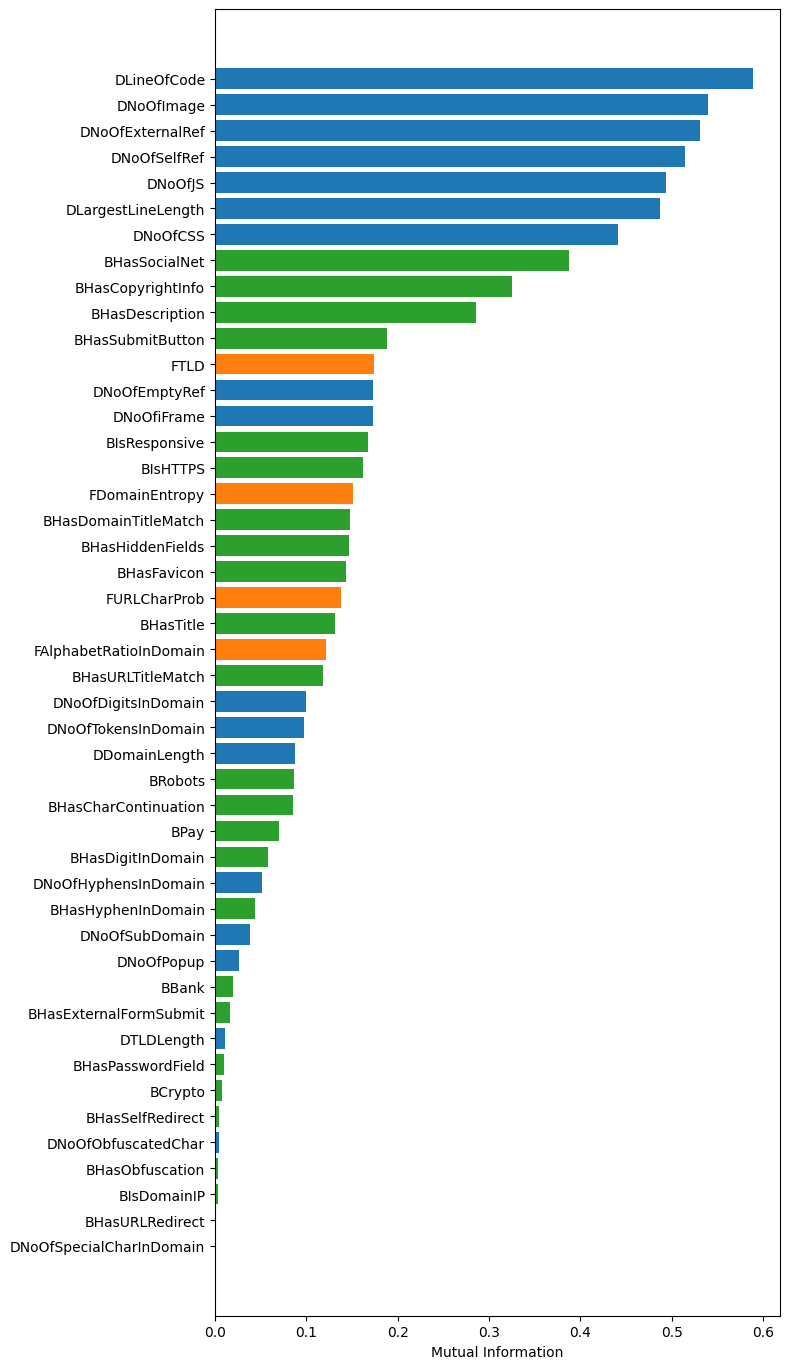

In [31]:
def feature_color(name):
    if name.startswith("D"):
        return "tab:blue"
    if name.startswith("F"):
        return "tab:orange"
    if name.startswith("B"):
        return "tab:green"
    return "gray"


mi = mi.sort_values(ascending=True)

plt.figure(figsize=(8, 0.3 * len(mi)))
plt.barh(
    mi.index,
    mi.values,
    color=[feature_color(f) for f in mi.index]
)
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.show()

In [6]:
select_binary_columns = [col for col in mi.index if col.startswith("B")][:4]
select_binary_columns

['BHasSocialNet', 'BHasCopyrightInfo', 'BHasDescription', 'BHasSubmitButton']

Based on the results of MI regression, the most important binary features are

- `HasSocialNet`
- `HasCopyrightInfo`
- `HasDescription`
- `HasSubmitButton`

## 1.2. Anova for floating point features

**Note:** We need to check for normality to apply ANOVA.

In [32]:
from sklearn.feature_selection import f_classif

numeric_columns = np.union1d(float_columns, discrete_columns)

F, pvals = f_classif(X[numeric_columns], y.values)

pd.DataFrame(
    {
        "feature": numeric_columns,
        "F": F,
        "pval": pvals,
    }
).sort_values("pval")

,feature,F,pval
0,DDomainLength,20137.656177,0.000000e+00
2,DLineOfCode,17623.237375,0.000000e+00
5,DNoOfEmptyRef,2708.506785,0.000000e+00
4,DNoOfDigitsInDomain,29423.902340,0.000000e+00
6,DNoOfExternalRef,15974.621949,0.000000e+00
7,DNoOfHyphensInDomain,21683.278026,0.000000e+00
9,DNoOfJS,35484.897574,0.000000e+00
8,DNoOfImage,18541.406358,0.000000e+00
15,DNoOfTokensInDomain,7110.000217,0.000000e+00
12,DNoOfSelfRef,24283.942975,0.000000e+00


All of the columns have very low p-values (nearly zero). So, we keep all of the floating point columns.

## 1.3. Wrapper Method: RFE

**Note:** Takes too long.

In [25]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)
rfe = RFE(model, step=1)
rfe.fit(X_train, y_train)
pd.Series(rfe.ranking_, index=X_train.columns).sort_values(ascending=True)

DDomainLength                1
FTLD                         1
FURLCharProb                 1
DTLDLength                   1
BHasURLRedirect              1
DLargestLineLength           1
DLineOfCode                  1
BIsHTTPS                     1
DNoOfJS                      1
BHasPasswordField            1
DNoOfImage                   1
BHasCopyrightInfo            1
BHasSocialNet                1
BBank                        1
BHasDescription              1
DNoOfSelfRef                 1
BHasCharContinuation         1
BHasDigitInDomain            1
BHasDomainTitleMatch         1
FAlphabetRatioInDomain       1
DNoOfHyphensInDomain         1
DNoOfDigitsInDomain          1
DNoOfExternalRef             1
BHasURLTitleMatch            2
DNoOfTokensInDomain          3
DNoOfObfuscatedChar          4
BCrypto                      5
BIsDomainIP                  6
FDomainEntropy               7
DNoOfEmptyRef                8
BPay                         9
BHasHiddenFields            10
BIsRespo

In [9]:
X_train.columns[rfe.get_support()]

Index(['BIsDomainIP', 'FTLD', 'FURLCharProb', 'DTLDLength', 'DNoOfSubDomain',
       'BHasObfuscation', 'DNoOfObfuscatedChar', 'BIsHTTPS', 'BHasTitle',
       'BHasFavicon', 'BHasURLRedirect', 'BHasDescription', 'DNoOfPopup',
       'BHasSocialNet', 'BHasSubmitButton', 'BHasHiddenFields',
       'BHasPasswordField', 'BHasCopyrightInfo', 'DNoOfDigitsInDomain',
       'DNoOfHyphensInDomain', 'FAlphabetRatioInDomain',
       'BHasCharContinuation', 'BHasDomainTitleMatch'],
      dtype='object')

## 1.4. Embedded Method: Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=-1, random_state=0)
rf.fit(X_train, y_train)
importances = pd.Series(
    data=rf.feature_importances_,
    index=X_train.columns,
).sort_values()

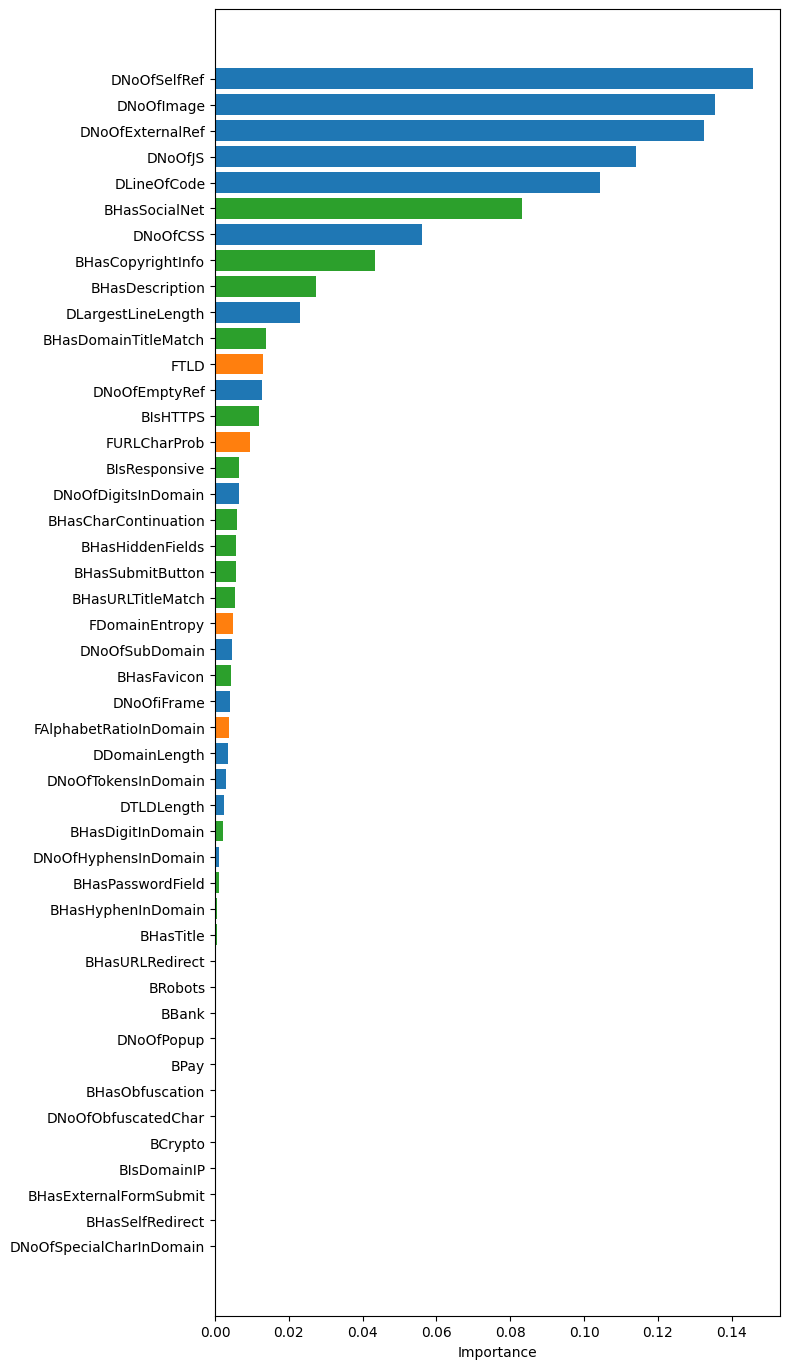

In [24]:
def feature_color(name):
    if name.startswith("D"):
        return "tab:blue"
    if name.startswith("F"):
        return "tab:orange"
    if name.startswith("B"):
        return "tab:green"
    return "gray"


plt.figure(figsize=(8, 0.3 * len(importances)))
plt.barh(
    importances.index,
    importances.values,
    color=[feature_color(f) for f in importances.index]
)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

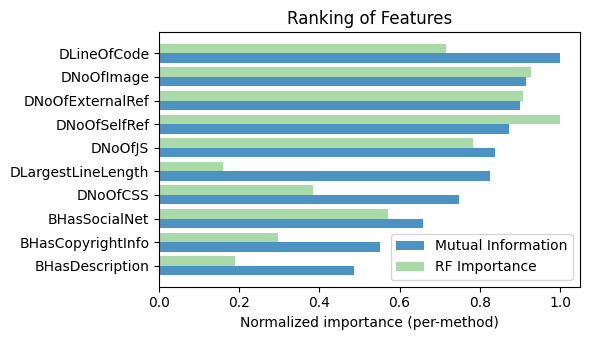

In [48]:
df = pd.concat(
    [mi.rename("MI"), importances.rename("RF")],
    axis=1
).dropna()

df["sum"] = df["MI"] + df["RF"]

df = df.sort_values("sum", ascending=True)
df = df.tail(10)

df.drop(columns="sum")

df_norm = df / df.max()

y = np.arange(len(df_norm))
h = 0.4

plt.figure(figsize=(6, 0.35 * len(df_norm)))

plt.barh(
    y - h/2,
    df_norm["MI"],
    height=h,
    label="Mutual Information",
    color="tab:blue",
    alpha=0.8
)

plt.barh(
    y + h/2,
    df_norm["RF"],
    height=h,
    label="RF Importance",
    color="tab:green",
    alpha=0.4
)

plt.yticks(y, df_norm.index)
plt.title("Ranking of Features")
plt.xlabel("Normalized importance (per-method)")
plt.legend()
plt.tight_layout()
plt.show()


## Permutation Importance

In [36]:
from sklearn.inspection import permutation_importance

rf = RandomForestClassifier(n_jobs=-1, random_state=0)
rf.fit(X_train, y_train)

perm = permutation_importance(
    rf,
    X_train,
    y_train,
    n_repeats=10,
    random_state=0,
    n_jobs=-1,
)

perm_importances = pd.Series(
    perm.importances.mean(),
    index=X_train.columns,
).sort_values(ascending=False)

perm_importances

DDomainLength               0.000699
BIsDomainIP                 0.000699
FTLD                        0.000699
FURLCharProb                0.000699
DTLDLength                  0.000699
DNoOfSubDomain              0.000699
BHasObfuscation             0.000699
DNoOfObfuscatedChar         0.000699
BIsHTTPS                    0.000699
DLineOfCode                 0.000699
DLargestLineLength          0.000699
BHasTitle                   0.000699
BHasFavicon                 0.000699
BRobots                     0.000699
BIsResponsive               0.000699
BHasURLRedirect             0.000699
BHasSelfRedirect            0.000699
BHasDescription             0.000699
DNoOfPopup                  0.000699
DNoOfiFrame                 0.000699
BHasExternalFormSubmit      0.000699
BHasSocialNet               0.000699
BHasSubmitButton            0.000699
BHasHiddenFields            0.000699
BHasPasswordField           0.000699
BBank                       0.000699
BPay                        0.000699
B

## 1.5. L1-Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from joblib import Parallel, delayed

Cs = [1.0, 0.5, 0.1, 0.05, 0.01]


def fit_model(C):
    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C=C,
                    max_iter=500,
                    random_state=0,
                ),
            ),
        ]
    )
    pipe.fit(X_train, y_train)
    return pipe


models = Parallel(n_jobs=-1, backend="loky")(delayed(fit_model)(C) for C in Cs)
models = dict(zip(Cs, models))

/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Webs

In [27]:
for C, model in models.items():
    coefs = model.named_steps["clf"].coef_.ravel()
    print(f"{C}: {coefs}")

1.0: [ 1.7899423  -0.09321168  1.0926423   1.32189333 -0.95467177  0.08525309
 -0.07485387 -0.34348043  2.4993695   3.30592973 -1.70517752  0.80285253
  0.1370401  -0.07353887 -0.11959985 -0.29248594  0.          0.77470599
  0.08881473 -0.0706918  -0.0147605   1.0296452   0.05932433  0.06472866
 -0.54025155 -0.35242149 -0.16917175 -0.02830596  0.84490987  1.66577028
  0.02723546  1.18155577  1.99424536  0.24439569  1.71888413 -1.10199381
 -0.65578341 -0.01780166 -2.66267683 -0.6252728  -0.22615205  0.86720727
  1.25017433  1.42916565 -0.13091899  0.47153072]
0.5: [ 1.61923145e+00 -1.44806485e-01  1.07403621e+00  1.28377942e+00
 -9.43182964e-01  1.31824944e-01 -1.25134445e-01 -2.54889035e-01
  2.43062934e+00  3.26874608e+00 -1.66936634e+00  7.46008265e-01
  1.32389738e-01 -6.24231033e-02 -1.17317669e-01 -2.86164147e-01
  0.00000000e+00  7.58666579e-01  8.13538557e-02 -6.47436272e-02
 -2.67043626e-03  1.01313261e+00  5.67664253e-02  5.58258124e-02
 -5.29101113e-01 -3.43574860e-01 -1.593

In [28]:
pd.Series(
    data=models[0.01].named_steps["clf"].coef_.ravel(),
    index=X_train.columns,
).abs().sort_values(ascending=True)

DDomainLength               0.000000
BIsDomainIP                 0.000000
BIsResponsive               0.000000
BHasTitle                   0.000000
BHasFavicon                 0.000000
BRobots                     0.000000
DNoOfPopup                  0.000000
BHasSelfRedirect            0.000000
BCrypto                     0.000000
BPay                        0.000000
BHasSubmitButton            0.000000
BHasHiddenFields            0.000000
BHasExternalFormSubmit      0.000000
DNoOfiFrame                 0.000000
DNoOfSpecialCharInDomain    0.000000
DNoOfTokensInDomain         0.000000
BHasHyphenInDomain          0.000000
FDomainEntropy              0.007299
BHasObfuscation             0.030438
DNoOfObfuscatedChar         0.036008
DNoOfEmptyRef               0.044185
BHasDigitInDomain           0.067165
BHasURLRedirect             0.109181
DNoOfCSS                    0.159995
BHasURLTitleMatch           0.177526
BBank                       0.196812
DNoOfHyphensInDomain        0.204072
B

# 3. Model Assumptions

## 3.1. Linearity of Logit

In [10]:
import statsmodels.api as sm

X_bt = X.copy()

for c in float_columns:
    X_bt[f"{c}_log"] = X[c] * np.log(X[c].clip(lower=1e-6))

X_bt = sm.add_constant(X_bt)
model = sm.Logit(y, X_bt).fit(disp=0)

bt_terms = [c for c in X_bt.columns if c.endswith("_log")]
model.pvalues[bt_terms]

/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


FTLD_log                      2.835285e-02
FURLCharProb_log              8.946598e-01
FAlphabetRatioInDomain_log    3.073186e-26
FDomainEntropy_log            8.121487e-31
dtype: float64

In [11]:
model.pvalues[bt_terms] < 0.05

FTLD_log                       True
FURLCharProb_log              False
FAlphabetRatioInDomain_log     True
FDomainEntropy_log             True
dtype: bool

All p-values are significant ($\alpha = 0.05$), except for `URLCharProb`.

## 3.2. No Perfect Multicollinearity

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_ = X.drop(columns=["FAlphabetRatioInDomain"])

X_vif = sm.add_constant(X_)

vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i)
     for i in range(1, X_vif.shape[1])],
    index=X_.columns
)

vif.sort_values(ascending=False)

DNoOfHyphensInDomain        4.572469
DDomainLength               4.148537
BHasDomainTitleMatch        4.055206
BHasURLTitleMatch           3.989590
DNoOfTokensInDomain         3.617471
BHasHyphenInDomain          3.270653
FDomainEntropy              3.259636
DNoOfDigitsInDomain         2.540251
BHasSocialNet               2.489059
BHasCharContinuation        2.475879
DNoOfSelfRef                2.274784
DNoOfSubDomain              2.216935
BHasCopyrightInfo           2.185245
DNoOfExternalRef            2.063275
BHasDigitInDomain           2.031859
BHasSubmitButton            1.980220
BHasDescription             1.940785
FURLCharProb                1.884786
BIsHTTPS                    1.818069
BIsResponsive               1.792139
BHasHiddenFields            1.740538
BHasTitle                   1.531219
BHasSelfRedirect            1.451481
FTLD                        1.451353
DTLDLength                  1.442969
BHasFavicon                 1.419775
BHasURLRedirect             1.418080
D

We have some problematic columns:
- `FAlphabetRatioInDomain`
- `DNoOfDigitsInDomain`
- `DDomainLength`

All of these features and some other features related to domain have high VIF.

Apply Box-Cox to strictly positive variables and Yeo-Johnson to the rest.

In [8]:
numeric_columns = np.union1d(discrete_columns, float_columns)

q = (X_train[numeric_columns] <= 0).sum() == 0
box_cox_columns = q[q].index
yeo_johnson_columns = q[~q].index

In [ ]:
skew_before = X_train[numeric_columns].skew()
kurt_before = X_train[numeric_columns].kurtosis(fis)

In [10]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="box-cox", standardize=True)

pt.fit(X_train[box_cox_columns])

X_train[box_cox_columns] = pd.DataFrame(pt.transform(X_train[box_cox_columns]), columns=box_cox_columns, index=X_train.index)
X_test[box_cox_columns] = pd.DataFrame(pt.transform(X_test[box_cox_columns]), columns=box_cox_columns, index=X_test.index)

pt = PowerTransformer(method="yeo-johnson", standardize=True)

pt.fit(X_train[yeo_johnson_columns])

X_train[yeo_johnson_columns] = pd.DataFrame(pt.transform(X_train[yeo_johnson_columns]), columns=yeo_johnson_columns, index=X_train.index)
X_test[yeo_johnson_columns] = pd.DataFrame(pt.transform(X_test[yeo_johnson_columns]), columns=yeo_johnson_columns, index=X_test.index)

In [12]:
skew_after = X_train[numeric_columns].skew()
kurt_after = X_train[numeric_columns].kurtosis()

In [11]:
#we need to combine X_train and y_train to save the transformed files
train_transformed = pd.concat([X_train, y_train], axis=1)
test_transformed = pd.concat([X_test, y_test], axis=1)
train_transformed.to_csv("feature-engineering-transform-train.csv", index=False)
test_transformed.to_csv("feature-engineering-transform-test.csv", index=False)

In [17]:
pd.DataFrame(
    (skew_before, skew_after, kurt_before, kurt_after),
    index=["SkewBefore", "SkewAfter", "KurtBefore", "KurtAfter"],
).T

,SkewBefore,SkewAfter,KurtBefore,KurtAfter
DDomainLength,2.463667,-0.051422,10.279324,2.994541
DLargestLineLength,49.231017,0.000207,3338.620676,-0.800116
DLineOfCode,57.665536,-0.111730,6311.613306,-0.921475
DNoOfCSS,16.054278,0.129572,987.192240,-1.367772
DNoOfDigitsInDomain,4.728471,1.452811,29.072196,0.130009
DNoOfEmptyRef,128.683952,0.860999,30945.640514,-1.133670
DNoOfExternalRef,56.760700,0.056387,7211.088886,-1.395996
DNoOfHyphensInDomain,4.514028,1.782051,42.087929,1.175979
DNoOfImage,27.273605,0.048078,1520.821747,-1.454168
DNoOfJS,151.816026,0.011164,40042.254325,-1.435252


## Check assumption

In [25]:
import statsmodels.api as sm

X_bt = X_train.select_dtypes(exclude=["object"]).copy()

for c in X_bt.columns:
    X_bt[f"{c}_log"] = X_bt[c] * np.log(X_bt[c].clip(lower=1e-6))

X_bt = sm.add_constant(X_bt)
model = sm.Logit(y_train, X_bt).fit(disp=0)

bt_terms = [c for c in X_bt.columns if c.endswith("_log")]
model.pvalues[bt_terms]

LinAlgError: Singular matrix

In [29]:
X_train.corr()

,DDomainLength,BIsDomainIP,FTLD,FURLCharProb,DTLDLength,DNoOfSubDomain,BHasObfuscation,DNoOfObfuscatedChar,BIsHTTPS,DLineOfCode,...,DNoOfHyphensInDomain,DNoOfSpecialCharInDomain,FAlphabetRatioInDomain,DNoOfTokensInDomain,FDomainEntropy,BHasCharContinuation,BHasDigitInDomain,BHasDomainTitleMatch,BHasHyphenInDomain,BHasURLTitleMatch
DDomainLength,1.000000,-0.053004,-0.169511,-0.093202,0.134367,0.359531,0.018850,0.018683,-0.012165,-0.123128,...,0.350741,0.008832,0.139999,0.421102,0.866731,-0.399259,-0.259172,-0.222308,0.332772,-0.276436
BIsDomainIP,-0.053004,1.000000,-0.008333,-0.085966,-0.129643,-0.103723,-0.002142,-0.002210,-0.083031,-0.047831,...,-0.022011,0.037010,-0.116156,0.020261,-0.086861,-0.055824,-0.084970,-0.044323,-0.021337,-0.047573
FTLD,-0.169511,-0.008333,1.000000,0.353308,-0.083598,0.045999,-0.029305,-0.030277,0.244381,0.407015,...,-0.212256,-0.004409,0.175167,-0.128244,-0.208316,0.205594,0.254328,0.197720,-0.204211,0.171824
FURLCharProb,-0.093202,-0.085966,0.353308,1.000000,0.058153,-0.025033,-0.053008,-0.054017,0.141073,0.361356,...,-0.186554,-0.013065,0.434673,-0.156981,-0.226008,0.335400,0.413017,0.316195,-0.179669,0.273323
DTLDLength,0.134367,-0.129643,-0.083598,0.058153,1.000000,0.217619,-0.000583,-0.001230,0.218383,-0.062378,...,0.009823,-0.008635,0.134417,-0.046263,0.163075,0.103953,-0.032828,0.123654,0.010324,0.122101
DNoOfSubDomain,0.359531,-0.103723,0.045999,-0.025033,0.217619,1.000000,-0.002432,-0.003586,0.129745,0.040501,...,0.025226,-0.013587,-0.236520,0.422011,0.218760,-0.353830,-0.087730,-0.178858,0.023264,-0.257290
BHasObfuscation,0.018850,-0.002142,-0.029305,-0.053008,-0.000583,-0.002432,1.000000,0.969510,-0.008961,-0.020491,...,0.009548,-0.000454,0.006967,0.012233,0.015714,-0.026587,-0.010622,-0.041697,0.009073,-0.030707
DNoOfObfuscatedChar,0.018683,-0.002210,-0.030277,-0.054017,-0.001230,-0.003586,0.969510,1.000000,-0.009687,-0.020690,...,0.008814,-0.000469,0.007235,0.011259,0.015934,-0.026557,-0.010707,-0.042797,0.008401,-0.031140
BIsHTTPS,-0.012165,-0.083031,0.244381,0.141073,0.218383,0.129745,-0.008961,-0.009687,1.000000,0.569019,...,-0.018812,-0.007825,0.100408,-0.060285,-0.002834,0.087531,0.073970,0.178309,-0.018055,0.179890
DLineOfCode,-0.123128,-0.047831,0.407015,0.361356,-0.062378,0.040501,-0.020491,-0.020690,0.569019,1.000000,...,-0.208730,-0.011445,0.165684,-0.118612,-0.175088,0.303066,0.234525,0.420710,-0.202193,0.379446


In [ ]:
model.pvalues[bt_terms] < 0.05

FTLD_log                       True
FURLCharProb_log              False
FAlphabetRatioInDomain_log     True
FDomainEntropy_log             True
dtype: bool

# 5. PCA

In [33]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_train_ = X_train.select_dtypes(exclude=["object"])

X_train_scaled = StandardScaler().fit_transform(X_train_)
pca = PCA(random_state=0)
X_train_pca = pca.fit_transform(X_train_scaled)
#we will save the file for PCA transformed data
#we need to dimencion reduction to explain 85% variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(explained_variance >= 0.85) + 1
n_components
pca = PCA(n_components=n_components, random_state=0)
X_train_pca = pca.fit_transform(X_train_scaled)
#we need to combine X_train and y_train to save the transformed files
train_pca = pd.concat([pd.DataFrame(X_train_pca), y_train.reset_index(drop=True)], axis=1)
train_pca.to_csv("feature-engineering-pca-train.csv", index=False)
# we need to apply to test data as well we need to apply standard scaling to binary columns only bc we already apply rest of it
X_test_ = X_test.select_dtypes(exclude=["object"])
# we need to apply to binary columns only bc we already apply rest of it
X_test_scaled = StandardScaler().fit_transform(X_test_)
X_test_pca = pca.transform(X_test_scaled)
# combine X_test and y_test to save the transformed files
test_pca = pd.concat([pd.DataFrame(X_test_pca), y_test.reset_index(drop=True)], axis=1)
test_pca.to_csv("feature-engineering-pca-test.csv", index=False)

In [34]:
pca.explained_variance_ratio_

array([0.27545572, 0.08131098, 0.04648434, 0.04309698, 0.03790952,
       0.03714822, 0.03411467, 0.03006261, 0.02633389, 0.02335592,
       0.0223776 , 0.0216925 , 0.0213453 , 0.02046113, 0.01974692,
       0.01818171, 0.01779043, 0.01618408, 0.01530956, 0.01495805,
       0.01414179, 0.01353304])

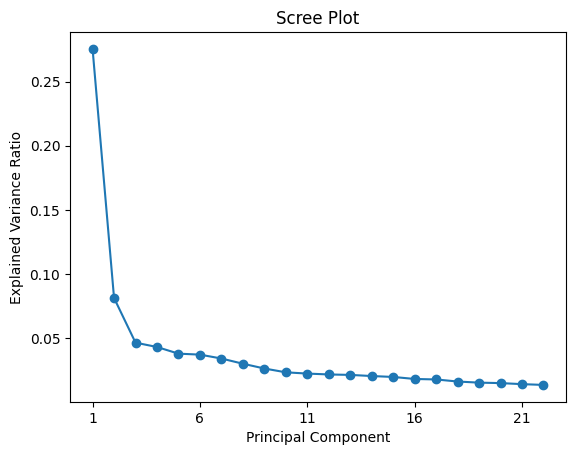

In [35]:
evr = pca.explained_variance_ratio_
n = len(evr)

plt.figure()
plt.plot(np.arange(1, n + 1), evr, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(np.arange(1, n + 1, 5))
plt.show()

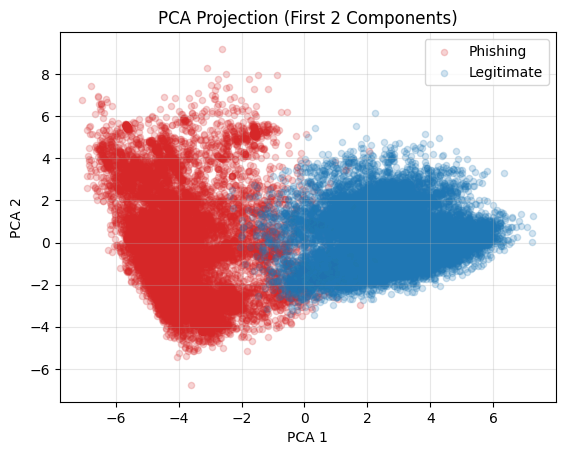

In [64]:
idx = np.random.choice(range(len(X_train_pca)), size=round(0.2 * len(X_train_pca)), replace=False)

X_ = X_train_pca[idx, :]
y_ = y_train[idx]

for label, color, name in zip([0, 1], ['tab:red', 'tab:blue'], ['Phishing', 'Legitimate']):
    plt.scatter(
        X_[y_ == label, 0],
        X_[y_ == label, 1],
        c=color,
        label=name,
        alpha=0.2,
        s=20
    )

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA Projection (First 2 Components)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# t-SNE and UMAP

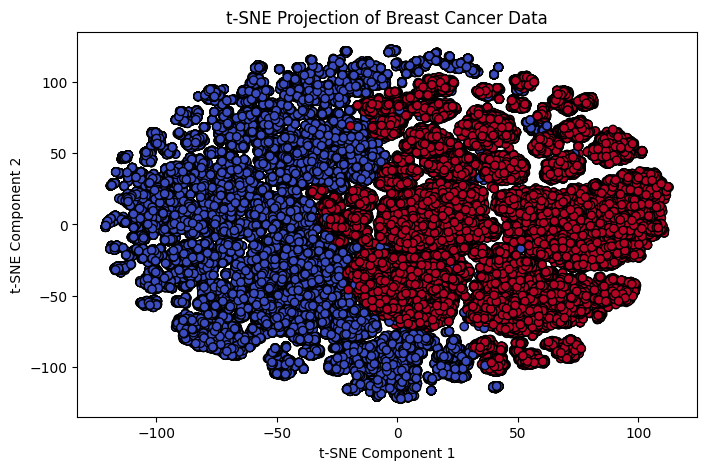

In [25]:
from sklearn.manifold import TSNE # Import the TSNE class

X_train_ = X_train.select_dtypes(exclude=["object"])

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train_)

plt.figure(figsize=(8, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Projection of Breast Cancer Data')
plt.show()

In [21]:
from sklearn.manifold import TSNE # Import the TSNE class

idx = np.random.choice(X_train.index, size=round(0.2 * len(X_train)), replace=False)
X_train_ = X_train.loc[idx].select_dtypes(exclude=["object"])
y_train_ = y_train.loc[idx]


def run_tsne(perp, X, y):
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        init="pca",
        #learning_rate=200,
        random_state=42,
    )
    X_tsne = tsne.fit_transform(X)

    plt.figure(figsize=(8, 5))
    plt.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=y,
        cmap="coolwarm",
        edgecolors="k",
    )
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.title(f"t-SNE Projection (Perplexity={perp})")
    plt.show()


perplexities = [5, 10, 20, 30, 50]

Parallel(n_jobs=-1)(
    delayed(run_tsne)(perp, X_train_, y_train_)
    for perp in perplexities
)

Figure(800x500)
Figure(800x500)
Figure(800x500)
Figure(800x500)
Figure(800x500)


[None, None, None, None, None]

/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


ValueError: 'c' argument has 156808 elements, which is inconsistent with 'x' and 'y' with size 31362.

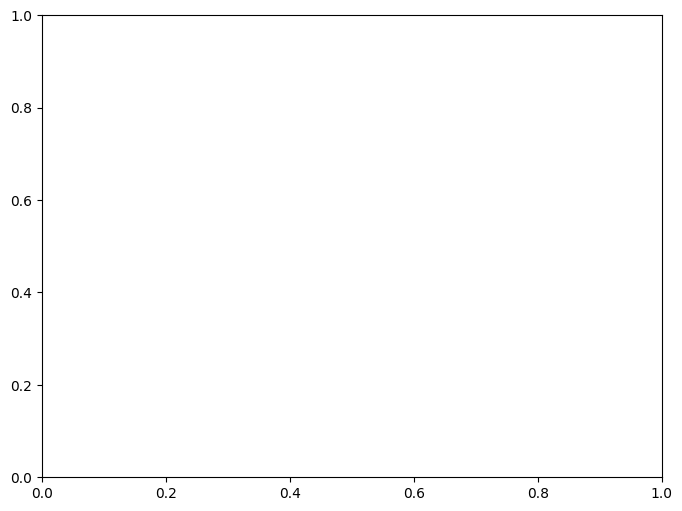

In [ ]:
import umap

# Example: X is your feature matrix (numpy array or DataFrame)
# X = data.drop(columns=["label"]).values

size = round(len(X_train) * 0.1)
idx = np.random.choice(X_train.index, size, replace=False)

X_ = X_train.loc[idx]

# Initialize UMAP
reducer = umap.UMAP(
    n_neighbors=100,  # controls local vs global structure
    min_dist=0.99,
    n_components=2,  # output dimensions
    metric="euclidean",  # distance metric
    random_state=42,
)

# Fit and transform
X_umap = reducer.fit_transform(X_)

# Convert to DataFrame for convenience
X_umap_df = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])

# Optional: plot if you have labels
if "y" in locals():  # assuming y is your label
    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_umap_df["UMAP1"],
        X_umap_df["UMAP2"],
        c=y_train.loc[idx],
        cmap="Spectral",
        s=10,
        alpha=0.7,
    )
    plt.colorbar(label="Label")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("UMAP projection")
    plt.show()

In [ ]:
from itertools import product


def run_umap(X, n_neighbors, min_dist):
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        metric="euclidean",
        random_state=0,
    )

    embedding = reducer.fit_transform(X)
    return {
        "n_neighbors": n_neighbors,
        "min_dist": min_dist,
        "embedding": embedding,
    }


min_dists = [0.0, 0.1, 0.25, 0.5, 0.8, 0.99]
n_neighbors = [2, 5, 10, 20, 50, 100, 200]

results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_umap)(X_, nn, md)
    for nn, md in product(n_neighbors, min_dists)
)


for res in results:
    emb = res["embedding"]

    plt.scatter(
        emb[:, 0],
        emb[:, 1],
        c=y_train.loc[idx],
        cmap="Spectral",
        s=8,
        alpha=0.4,
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP projections (parallel runs)")
plt.colorbar(label="Label")
plt.tight_layout()
plt.show()

/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/byron/Development/School/2025-1/ST